In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
import os
print("Current working directory:", os.getcwd())

Current working directory: d:\Project\Job\sales-analytics-dashboard


In [5]:
import pandas as pd

df = pd.read_csv("data/global_superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (51290, 24)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [8]:
df.isnull().sum().sort_values(ascending=False)

Postal Code       41296
Row ID                0
Order Date            0
Order ID              0
Ship Mode             0
Customer ID           0
Customer Name         0
Ship Date             0
Segment               0
City                  0
State                 0
Country               0
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Data Cleaning
We prepare the dataset for analysis by:
- converting date columns
- fixing postal code format
- creating new time features

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [11]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [12]:
df[["Order Date","Year","Month","Month Name","Quarter"]].head()

,Order Date,Year,Month,Month Name,Quarter
0,2012-07-31,2012,7,July,3
1,2013-02-05,2013,2,February,1
2,2013-10-17,2013,10,October,4
3,2013-01-28,2013,1,January,1
4,2013-11-05,2013,11,November,4


## Feature Engineering
We create business metrics needed for KPI reporting and dashboard analysis.

In [13]:
df["Profit Margin %"] = np.where(df["Sales"] != 0, (df["Profit"] / df["Sales"]) * 100, 0)
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [14]:
df[["Sales", "Profit", "Profit Margin %", "Order Date", "Ship Date", "Ship Days"]].head()

,Sales,Profit,Profit Margin %,Order Date,Ship Date,Ship Days
0,2309.650,762.1845,33.000000,2012-07-31,2012-07-31,0
1,3709.395,-288.7650,-7.784693,2013-02-05,2013-02-07,2
2,5175.171,919.9710,17.776630,2013-10-17,2013-10-18,1
3,2892.510,-96.5400,-3.337586,2013-01-28,2013-01-30,2
4,2832.960,311.5200,10.996272,2013-11-05,2013-11-06,1


In [15]:
month_order = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

df["Month Sort"] = df["Month Name"].map(month_order)

In [16]:
df[["Month Name", "Month Sort"]].drop_duplicates().sort_values("Month Sort")

,Month Name,Month Sort
3,January,1
1,February,2
27,March,3
7,April,4
22,May,5
5,June,6
0,July,7
20,August,8
17,September,9
2,October,10


In [17]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
avg_profit_margin = df["Profit Margin %"].mean()
avg_ship_days = df["Ship Days"].mean()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Profit Margin %:", round(avg_profit_margin, 2))
print("Average Shipping Days:", round(avg_ship_days, 2))

Total Sales: 12642501.91
Total Profit: 1467457.29
Total Orders: 25035
Total Customers: 1590
Average Profit Margin %: 4.74
Average Shipping Days: 3.97


In [18]:
monthly_sales = (
    df.groupby(["Year", "Month", "Month Name", "Month Sort"], as_index=False)["Sales"]
    .sum()
    .sort_values(["Year", "Month"])
)

monthly_sales.head(12)

,Year,Month,Month Name,Month Sort,Sales
0,2011,1,January,1,98898.48886
1,2011,2,February,2,91152.15698
2,2011,3,March,3,145729.36736
3,2011,4,April,4,116915.76418
4,2011,5,May,5,146747.83610
5,2011,6,June,6,215207.38022
6,2011,7,July,7,115510.41912
7,2011,8,August,8,207581.49122
8,2011,9,September,9,290214.45534
9,2011,10,October,10,199071.26404


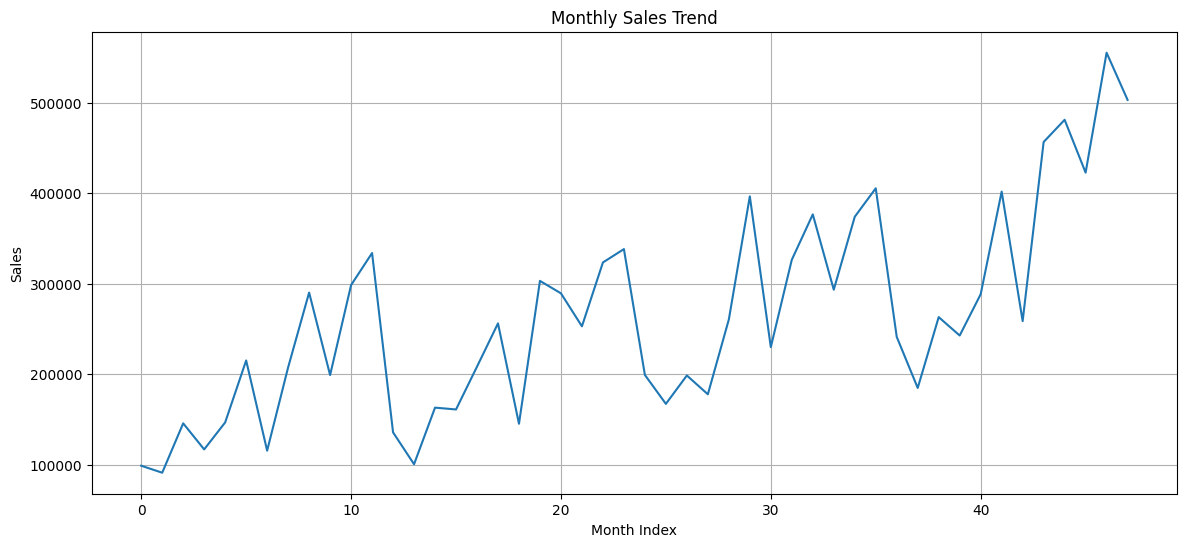

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales["Sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Month Index")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [20]:
sales_by_category = (
    df.groupby("Category", as_index=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

sales_by_category

,Category,Total_Sales,Total_Profit,Total_Quantity
2,Technology,4.744557e+06,663778.73318,35176
0,Furniture,4.110874e+06,285204.72380,34954
1,Office Supplies,3.787070e+06,518473.83430,108182


In [21]:
sales_by_region = (
    df.groupby("Region", as_index=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

sales_by_region.head(10)

,Region,Total_Sales,Total_Profit,Orders
3,Central,2.822303e+06,311403.98164,5249
10,South,1.600907e+06,140355.76618,3270
7,North,1.248166e+06,194597.95252,2356
9,Oceania,1.100185e+06,120089.11200,1744
11,Southeast Asia,8.844232e+05,17852.32900,1517
8,North Asia,8.483098e+05,165578.42100,1150
5,EMEA,8.061613e+05,43897.97100,2462
0,Africa,7.837732e+05,88871.63100,2232
4,Central Asia,7.528266e+05,132480.18700,1026
12,West,7.254578e+05,108418.44890,1611


In [22]:
top_products = (
    df.groupby("Product Name", as_index=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

top_products

,Product Name,Total_Sales,Total_Profit,Total_Quantity
310,"Apple Smart Phone, Full Size",86935.7786,5921.5786,171
970,"Cisco Smart Phone, Full Size",76441.5306,17238.5206,139
2415,"Motorola Smart Phone, Full Size",73156.3030,17027.1130,134
2501,"Nokia Smart Phone, Full Size",71904.5555,9938.1955,147
866,Canon imageCLASS 2200 Advanced Copier,61599.8240,25199.9280,20
1837,"Hon Executive Leather Armchair, Adjustable",58193.4841,5997.2541,169
2631,"Office Star Executive Leather Armchair, Adjust...",50661.6840,4710.9840,141
1714,"Harbour Creations Executive Leather Armchair, ...",50121.5160,10427.3260,142
2988,"Samsung Smart Phone, Cordless",48653.4600,-198.0900,108
2502,"Nokia Smart Phone, with Caller ID",47877.7857,9465.3257,96


In [23]:
segment_performance = (
    df.groupby("Segment", as_index=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

segment_performance

,Segment,Total_Sales,Total_Profit,Orders
0,Consumer,6.507949e+06,749239.78206,13104
1,Corporate,3.824698e+06,441208.32866,7673
2,Home Office,2.309855e+06,277009.18056,4687


In [24]:
discount_impact = (
    df.groupby("Discount", as_index=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Avg_Profit_Margin=("Profit Margin %", "mean")
    )
    .sort_values("Discount")
)

discount_impact.head(15)

,Discount,Total_Sales,Total_Profit,Avg_Profit_Margin
0,0.000,6.992411e+06,1.770695e+06,26.489807
1,0.002,2.613956e+05,5.797658e+04,22.866849
2,0.070,1.216169e+05,2.114850e+04,17.762667
3,0.100,1.579606e+06,2.590642e+05,16.455762
4,0.150,3.060298e+05,2.737590e+04,9.274813
5,0.170,2.473992e+05,2.816307e+04,10.741563
6,0.200,1.203832e+06,1.177159e+05,14.670511
7,0.202,1.621565e+04,-5.952727e+02,-0.351183
8,0.250,8.805535e+04,8.005875e+02,1.978869
9,0.270,8.935167e+04,-1.675079e+03,-0.901282


In [27]:
import os
os.listdir("..")

['Projects to focus on.txt', 'sales-analytics-dashboard']

In [29]:
df.to_csv("analysis/cleaned_sales_data.csv", index=False)

## Conclusion

Key findings:

• Technology drives the highest revenue.
• Consumer segment dominates total sales.
• Some regions generate revenue but very low profit.
• Sales show strong seasonality with Q4 peaks.
• Discounting can cause negative profit margins.

The dataset was cleaned and exported for Power BI dashboard development.